# Models exploration

## Hierachical approach
- Since we know the taxonomy, a 2 level hierachical approach can be applied
- Start from training models on clean audio sound

### 1. Top-down approach (hard hierarchical combination)
- Model 1 : predict family
- A. Model 1...n_families : predict species conditioned by the family OR B. Single global model with masking.

#### Inference. Hard combination
During inference, predict family, then predict species.

**Problem** : wrong family -> wrong species (error propagation)

#### Inference. Soft combination
If model outputs probabilities, then
$$
P(y|x) = P(family_y | x) \cdot P(y | x, family_y)
$$

Also, instead of training n_families models, one model can be trained to predict species, then (with hypothesis that model implicitely learned hierachy),

$$
P(y|x, family_y) = P(y|x)
$$

## Train/test separation
Simple stratification per labels

## Features
#### Features extraction 
0. Waveform [experimental purposes only, baseline]
1. MFCC (with delta, delta-delta)
2. Spectral features : useful since different species often occupy different frequency ranges.
- Spectral centroid -> "brightness"
- Spectral bandwidth -> spread of frequencies
- Spectral rolloff -> frequency below which X% energy lies
- Spectral contrast -> peaks vs valleys

3. RMS energy, zero-crossing rate (distinguish between tonal calls vs noisy env)

#### Pooling/aggregation
Since every audio is of different duration, extracted features must be aggregated.

##### Global pooling : 1 audio = 1 unit, aggregate over all frames
- Mean, std, max, min, percentiles, skewness & kurtosis

##### Chunking : 1 audio = N units/chunks, aggregate over chunks
- Split every audio into N chunks
- Aggregate per segment
- Concatenate aggregates features

## Questions
1. Training on clean audio, then how to adapt models to soundscape
2. Some classes are present only in soundscape, how to adapt models and detect these classes

In [10]:
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

import librosa
import librosa.display
import soundfile as sf

from IPython.display import Markdown

from birdclef_2026_ml.notebook_utils import init_notebook
from birdclef_2026_ml.paths import PATHS
from birdclef_2026_ml.audio_utils import load_train_audio
from birdclef_2026_ml.eda import *
from birdclef_2026_ml.preprocess import *
from birdclef_2026_ml.constants import SAMPLE_RATE

from birdclef_2026_ml.data_split import split_audio_train_val
from birdclef_2026_ml.feature_engineering import *

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
train = pd.read_parquet(PATHS["proc_train"])
soundscapes = pd.read_csv(PATHS["raw_soundscape_labels"])
taxonomy = pd.read_csv(PATHS["taxonomy"])
soundscapes = preprocess_soundscape(soundscapes)
soundscapes.head(5)

,filename,start,end,primary_label,primary_label_list,datetime
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,22961;23158;24321;517063;65380,"[22961, 23158, 24321, 517063, 65380]",2021-12-31 20:15:00


In [7]:
feat_cfg = FeatureConfig(include_waveform_stats=True,
                         include_mfcc=False,
                         include_delta=False, 
                         include_delta2=False,
                         include_energy=False,
                         include_spectral=False)
pool_cfg = PoolingConfig()
#X, features = extract_features_from_row(df=train, idx=0, feature_cfg=feat_cfg, pooling_mode="global", pooling_cfg=pool_cfg)

In [12]:
X, features = build_feature_matrix_from_df(train.head(100),
                                           feat_cfg,
                                           "global", 
                                           pool_cfg)

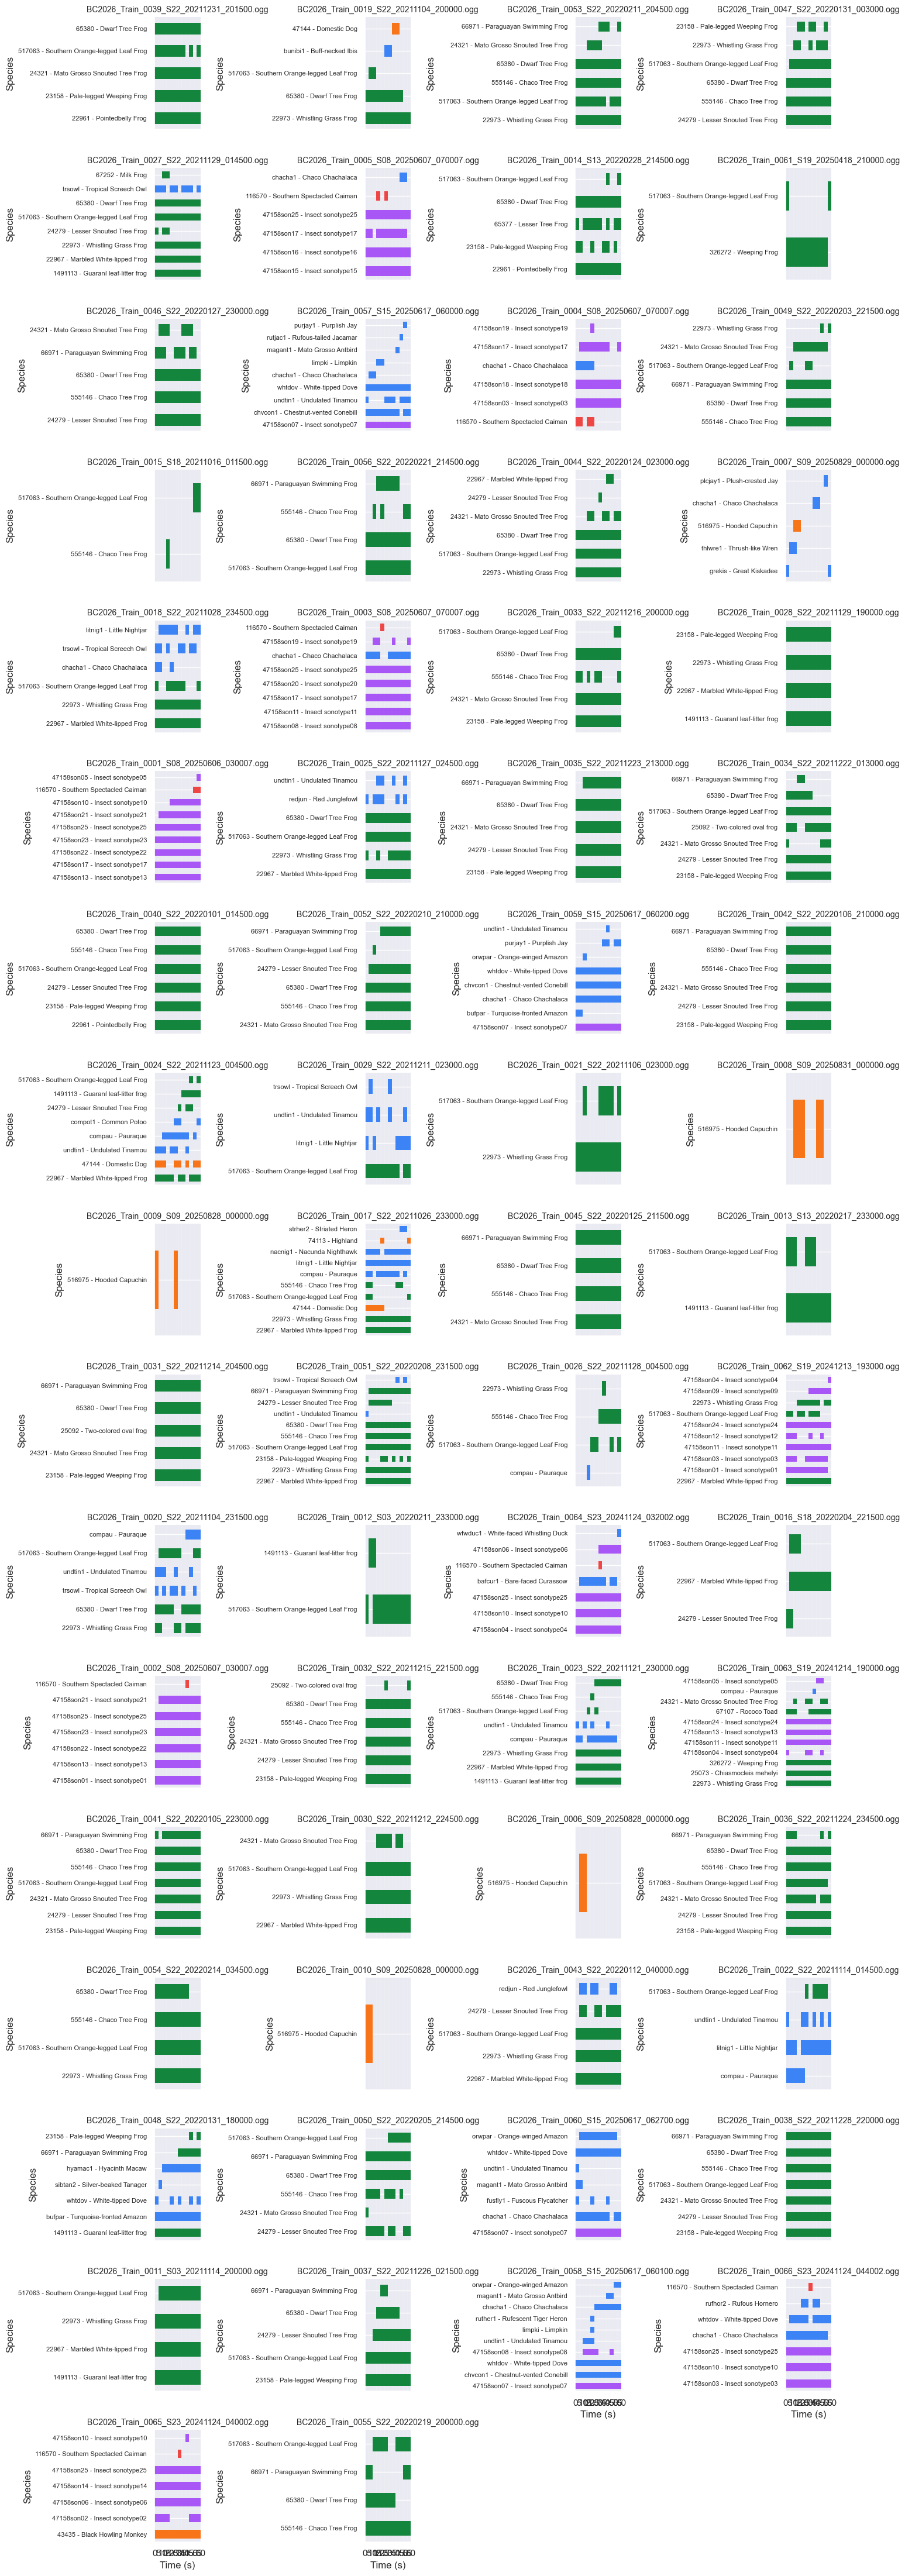

In [ ]:
g = sns.FacetGrid(
    soundscapes,
    col="filename",
    col_wrap=4,
    sharey=False,
    height=3,
    aspect=1.4
)

def draw_timeline(data, **kws):
    fname = data["filename"].iloc[0]
    plot_soundscape_species_activity(
    soundscapes=data,
    taxonomy=taxonomy,
    filename=fname,
    ax=plt.gca(),
    show_legend=False,
    title=fname
    )

g.map_dataframe(draw_timeline)
plt.tight_layout()

In [ ]:
taxonomy = pd.read_csv(PATHS["taxonomy"])
fig, axes = plt.subplots()

for filename in soundscapes["filename"].unique():
    example_filename = soundscapes["filename"].iloc[0]

# # Standalone plot (ax not provided -> function creates its own figure)
# ax = plot_soundscape_species_activity(
#     soundscapes=soundscapes,
#     taxonomy=taxonomy,
#     filename=example_filename,
# )

BC2026_Train_0039_S22_20211231_201500.ogg
BC2026_Train_0019_S22_20211104_200000.ogg
BC2026_Train_0053_S22_20220211_204500.ogg
BC2026_Train_0047_S22_20220131_003000.ogg
BC2026_Train_0027_S22_20211129_014500.ogg
BC2026_Train_0005_S08_20250607_070007.ogg
BC2026_Train_0014_S13_20220228_214500.ogg
BC2026_Train_0061_S19_20250418_210000.ogg
BC2026_Train_0046_S22_20220127_230000.ogg
BC2026_Train_0057_S15_20250617_060000.ogg
BC2026_Train_0004_S08_20250607_070007.ogg
BC2026_Train_0049_S22_20220203_221500.ogg
BC2026_Train_0015_S18_20211016_011500.ogg
BC2026_Train_0056_S22_20220221_214500.ogg
BC2026_Train_0044_S22_20220124_023000.ogg
BC2026_Train_0007_S09_20250829_000000.ogg
BC2026_Train_0018_S22_20211028_234500.ogg
BC2026_Train_0003_S08_20250607_070007.ogg
BC2026_Train_0033_S22_20211216_200000.ogg
BC2026_Train_0028_S22_20211129_190000.ogg
BC2026_Train_0001_S08_20250606_030007.ogg
BC2026_Train_0025_S22_20211127_024500.ogg
BC2026_Train_0035_S22_20211223_213000.ogg
BC2026_Train_0034_S22_20211222_013